In [1]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt

/home/leoperes/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:

f_list = ["../np02vd_raw_run039510_0000_df-s04-d0_dw_0_20250919T123428_0kV_gallery.root",
"../np02vd_raw_run039510_0001_df-s04-d0_dw_0_20250919T123526_0kV_gallery.root",
"../np02vd_raw_run039510_0002_df-s04-d0_dw_0_20250919T123624_0kV_gallery.root",
"../np02vd_raw_run039510_0003_df-s04-d0_dw_0_20250919T123722_0kV_gallery.root",
"../np02vd_raw_run039510_0004_df-s04-d0_dw_0_20250919T123821_0kV_gallery.root",
"../np02vd_raw_run039510_0005_df-s04-d0_dw_0_20250919T123919_0kV_gallery.root"]


chain = ROOT.TChain("WaveformTree")


for f_in in f_list:
    chain.Add(f_in)

n_entries = chain.GetEntries()
print(n_entries)


8292065


In [3]:
df = ROOT.RDataFrame(chain)

list_all_events = np.array(
    sorted(set(df.Take["int"]("event").GetValue())),
    dtype=int,
)

print(list_all_events)

[   1    2    3 ... 5967 5968 5969]


In [4]:
# -------------------------------------------------------
# Configuration
# -------------------------------------------------------
channels_dict = {
    "CH_M3_1": 2030, 
    "CH_M3_2": 2031, 
    "CH_M4_1": 2040, 
    "CH_M4_2": 2041, 
    "CH_M5_1": 2050, 
    "CH_M5_2": 2051, 
    "CH_M6_1": 2060, 
    "CH_M6_2": 2061,
    "CH_M7_1": 2070,
    "CH_M7_2": 2071,
    "CH_M8_1": 2080,
    "CH_M8_2": 2081
}

# Use 1 if one ADC sample corresponds to one timestamp tick.
# Keep the coincidence logic in timestamp units unless you have
# confirmed the timestamp conversion in the decoder source.
SAMPLE_TICKS = 1

# Initial coincidence window, in timestamp ticks.
# If 1 tick = 16 ns, then 125 ticks = 2 us.
COINCIDENCE_WINDOW_TICKS = 20

def baseline(waveform):
    """Calculate the baseline of a waveform."""
    return np.mean(waveform[0:300])

def signal_amplitude(waveform):
    waveform = np.asarray(waveform)
    signal_region = waveform[30:130]
    return np.max(signal_region) - np.min(signal_region)

def signal_peak_tick(waveform):
    waveform = np.asarray(waveform)
    signal_region = waveform[30:130]
    return 30 + int(np.argmax(signal_region))

def noise_rms(waveform):
    """Calculate the RMS of the noise in a waveform."""
    return np.std(waveform[0:300])

def preSignalAmplitude(waveform):
    """Calculate the pre-signal amplitude of a waveform."""
    return np.max(waveform[0:300]) - np.min(waveform[0:300])

def postSignalAmplitude(waveform):
    """Calculate the post-signal amplitude of a waveform."""
    return np.max(waveform[350:1023]) - np.min(waveform[350:1023])

def Waveforms_Coincidence_byAmplitude(waveform_1, waveform_2, timestamp_1, timestamp_2, threshold):
    """Check if two waveforms are in coincidence based on amplitude threshold."""
    amp1 = signal_amplitude(waveform_1)
    amp2 = signal_amplitude(waveform_2)
    tick_amp1 = signal_peak_tick(waveform_1)
    tick_amp2 = signal_peak_tick(waveform_2)


    if amp1 > threshold and amp2 > threshold and abs(tick_amp1 - tick_amp2) <= COINCIDENCE_WINDOW_TICKS and timestamp_1 == timestamp_2:
        return True
    else:
        return False

In [5]:
from matplotlib.colors import LogNorm

valid_channels = np.array(sorted(channels_dict.values()), dtype=int)
valid_channel_set = set(valid_channels)

# Read only needed branches
chain.SetBranchStatus("*", 0)
chain.SetBranchStatus("channel", 1)
chain.SetBranchStatus("adc", 1)

n_adc_bins = 100
adc_min, adc_max = 0, 16384

# Get n_samples from first selected waveform
n_samples = None
for i in range(n_entries):
    chain.GetEntry(i)
    if int(chain.channel) in valid_channel_set:
        n_samples = len(chain.adc)
        break

sample_idx = np.arange(n_samples)

hist_by_channel = {
    ch: np.zeros((n_samples, n_adc_bins), dtype=np.uint32)
    for ch in valid_channels
}
counts_by_channel = {ch: 0 for ch in valid_channels}

count = 0

for entry in range(n_entries):
    chain.GetEntry(entry)

    ch = int(chain.channel)
    if ch not in valid_channel_set:
        continue

    wf = np.asarray(chain.adc, dtype=np.float32)

    adc_bin = ((wf - adc_min) * n_adc_bins / (adc_max - adc_min)).astype(np.int32)
    adc_bin = np.clip(adc_bin, 0, n_adc_bins - 1)

    np.add.at(hist_by_channel[ch], (sample_idx, adc_bin), 1)

    counts_by_channel[ch] += 1
    count += 1

print(f"Total waveforms collected: {count}")

Total waveforms collected: 2482360


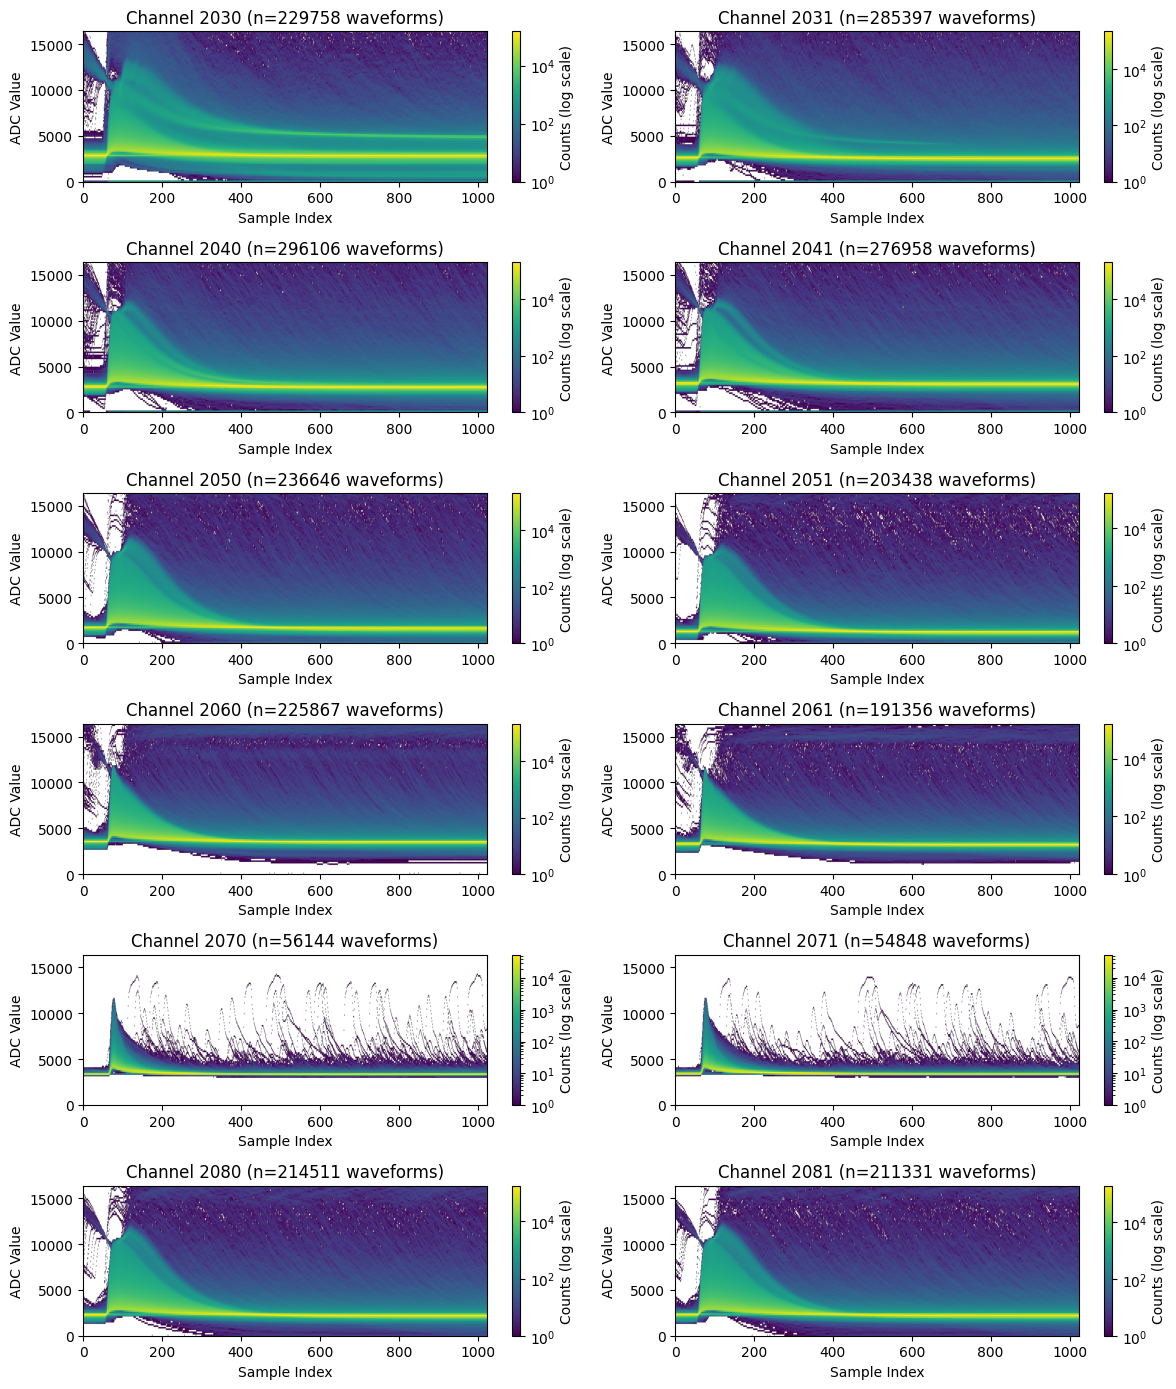

In [22]:
fig, ax = plt.subplots(6, 2, figsize=(12, 14))
axes = dict(zip(valid_channels, ax.flatten()))

for ch in valid_channels:
    h = hist_by_channel[ch]

    if counts_by_channel[ch] == 0:
        continue

    im = axes[ch].imshow(
        h.T,
        origin="lower",
        aspect="auto",
        extent=[0, n_samples, adc_min, adc_max],
        cmap="viridis",
        norm=LogNorm(vmin=1),
    )

    axes[ch].set_xlabel("Sample Index")
    axes[ch].set_ylabel("ADC Value")
    axes[ch].set_title(f"Channel {ch} (n={counts_by_channel[ch]} waveforms)")
    plt.colorbar(im, ax=axes[ch], label="Counts (log scale)")


plt.tight_layout()
plt.savefig("allwaveforms_allarapucas.pdf", bbox_inches="tight", transparent=True)
plt.savefig("allwaveforms_allarapucas.png", bbox_inches="tight", transparent=True)
plt.show()

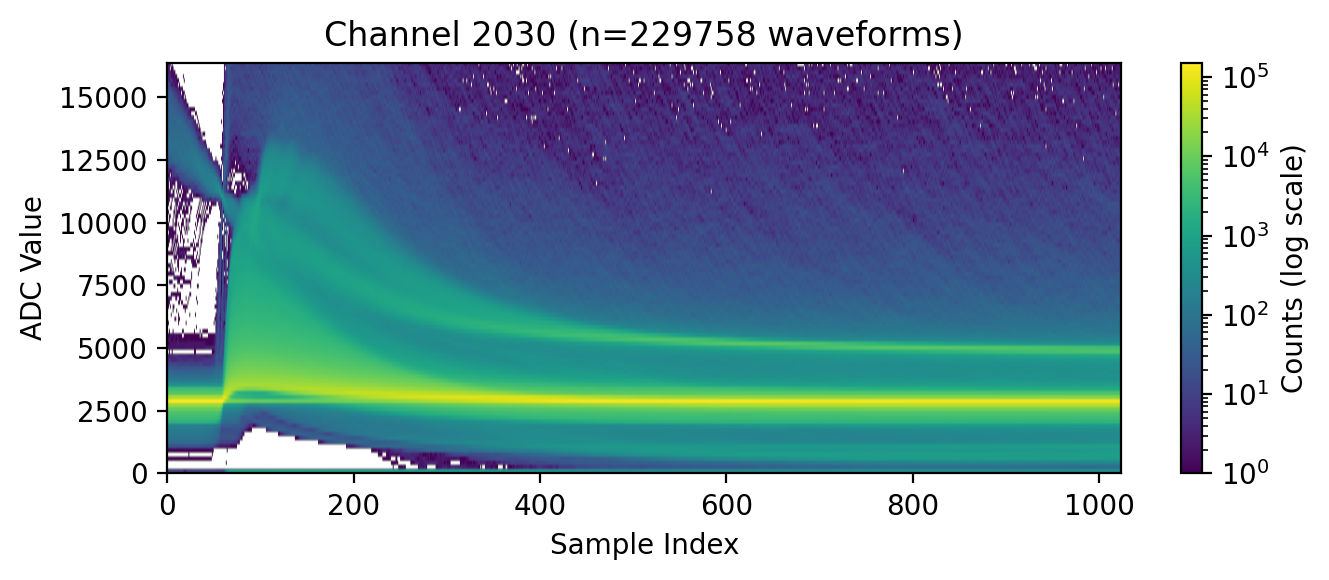

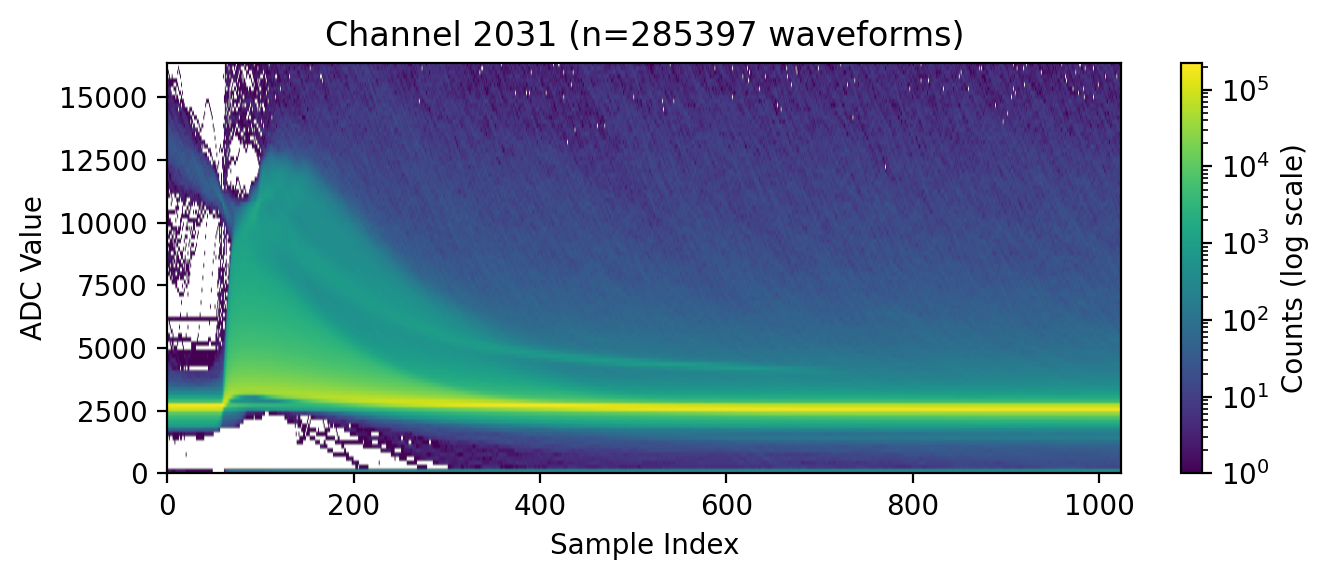

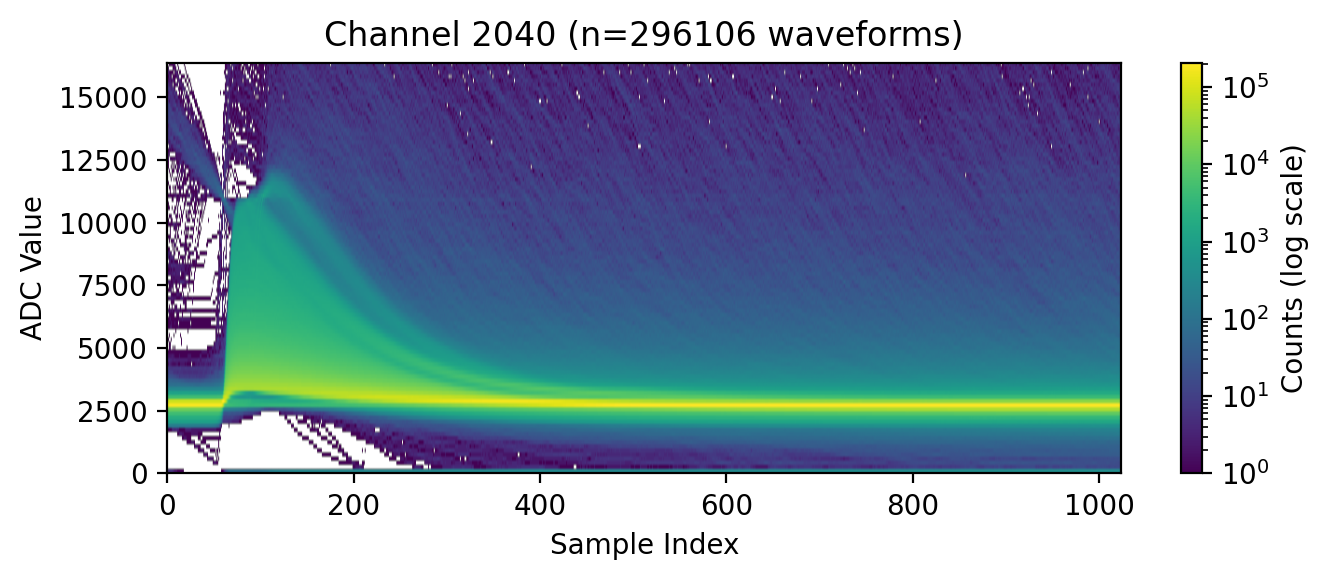

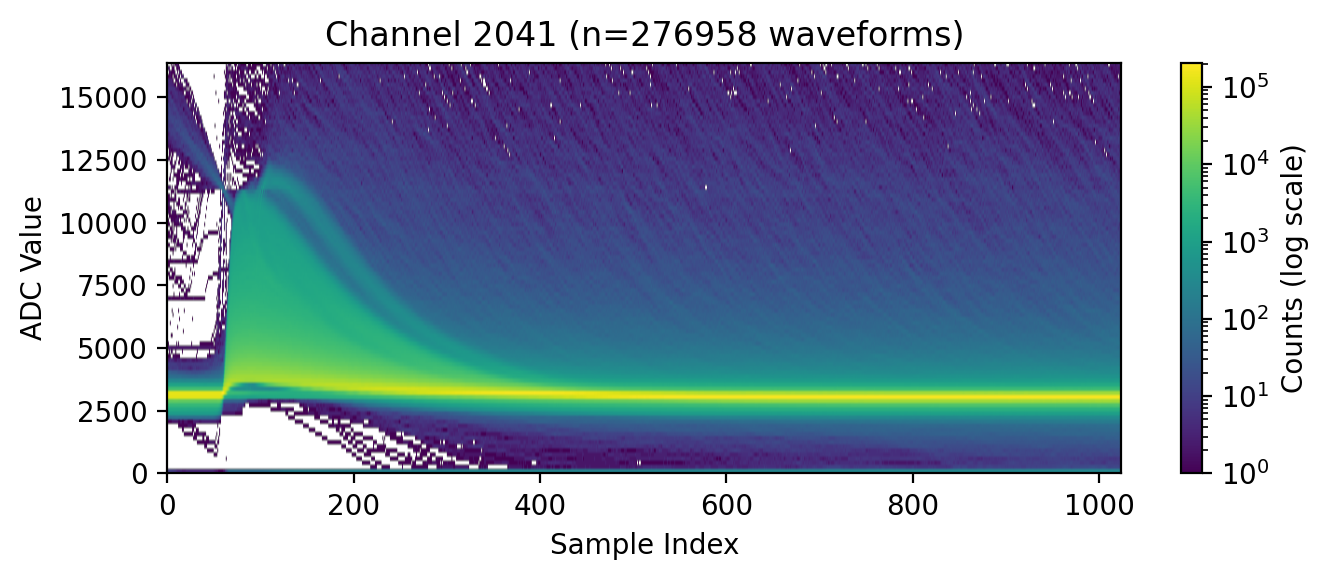

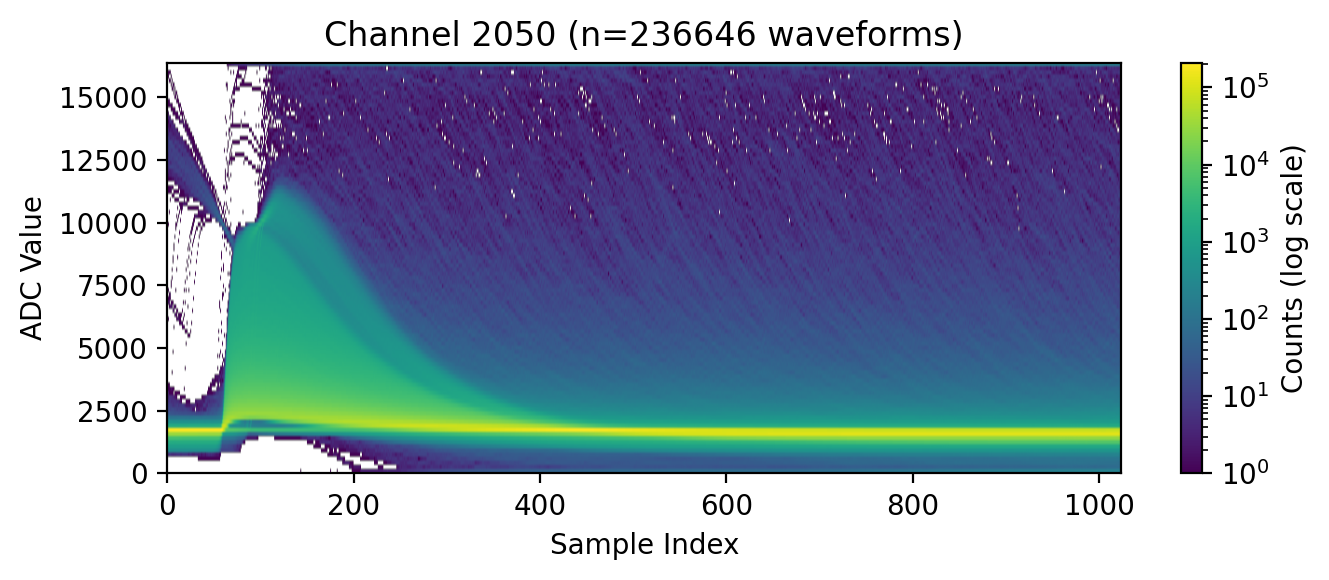

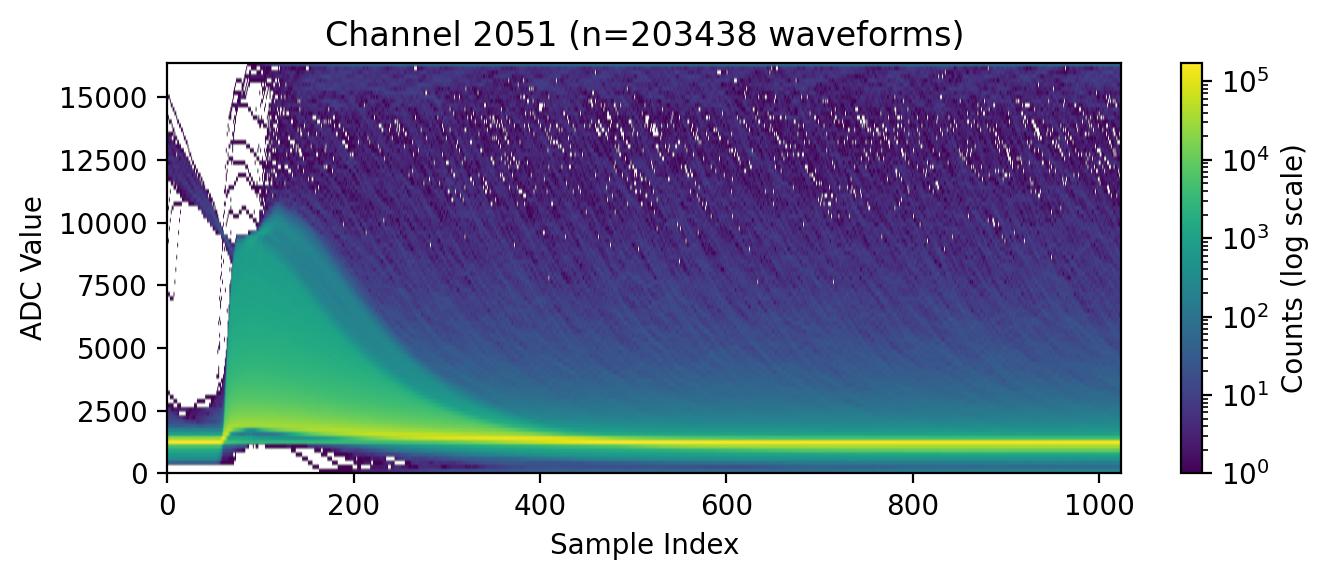

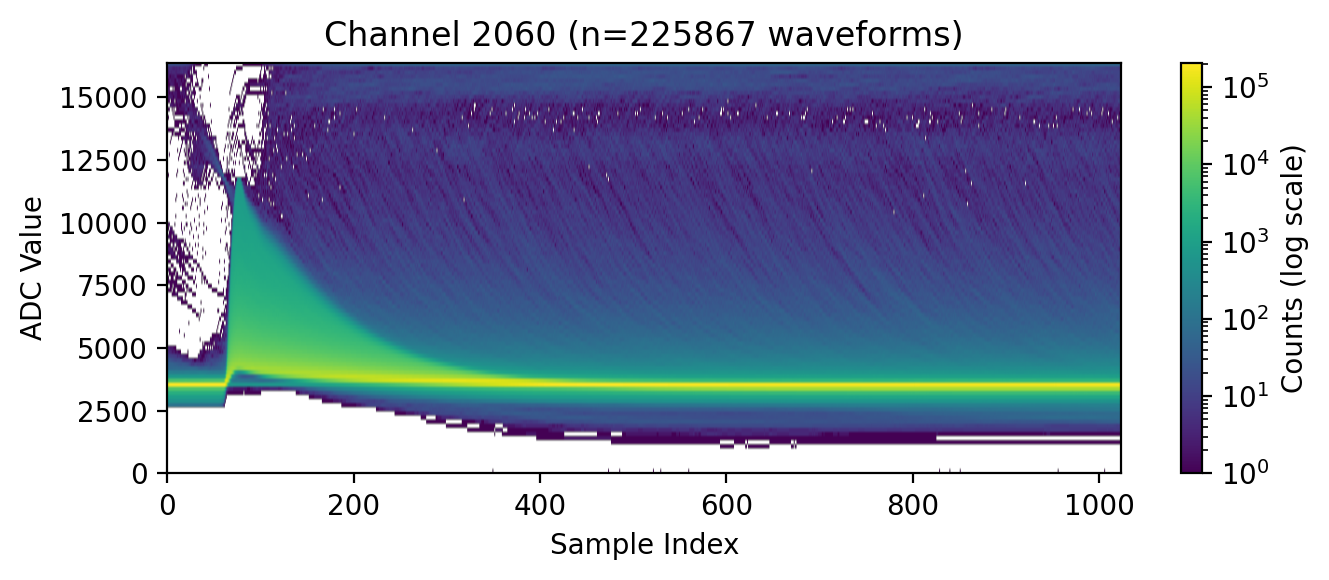

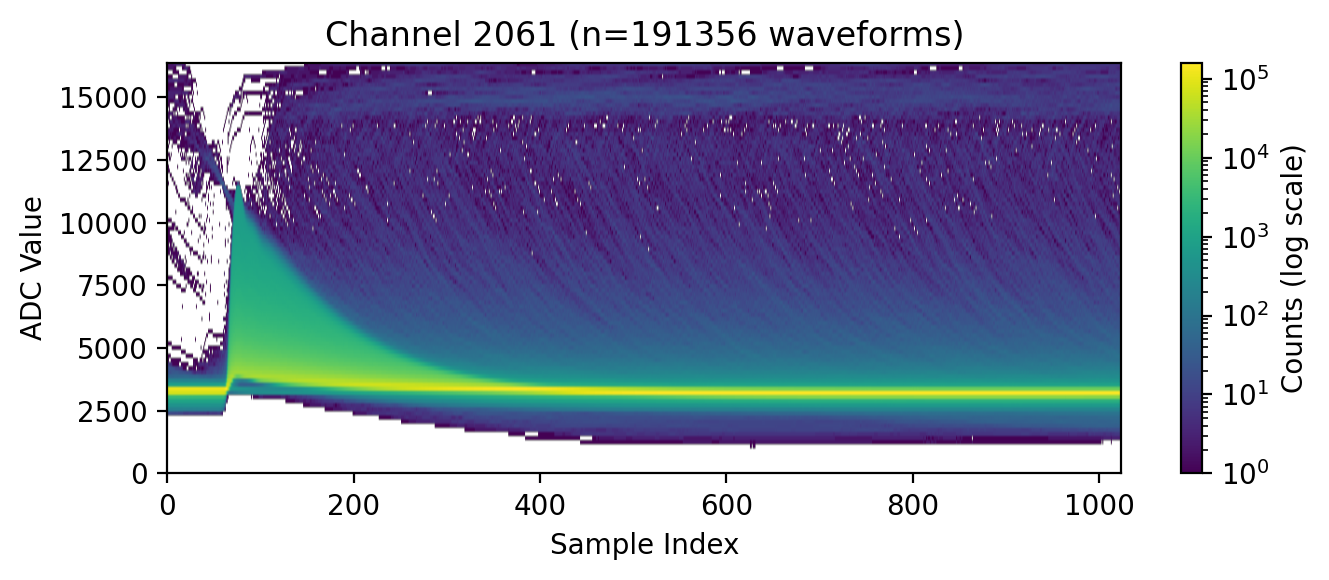

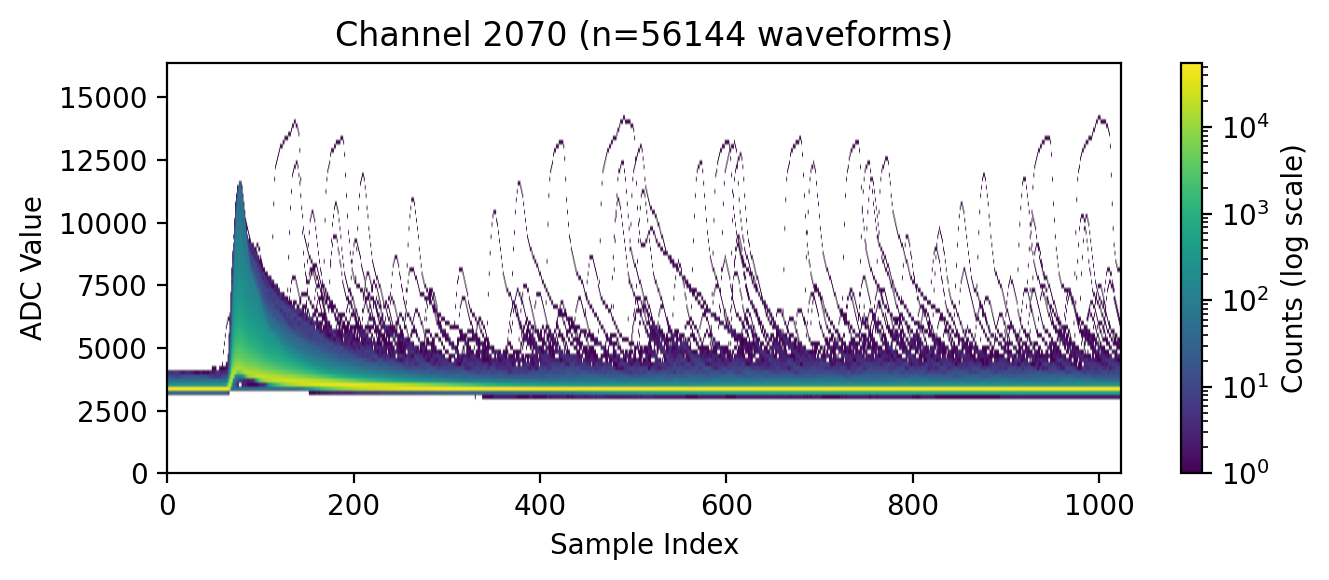

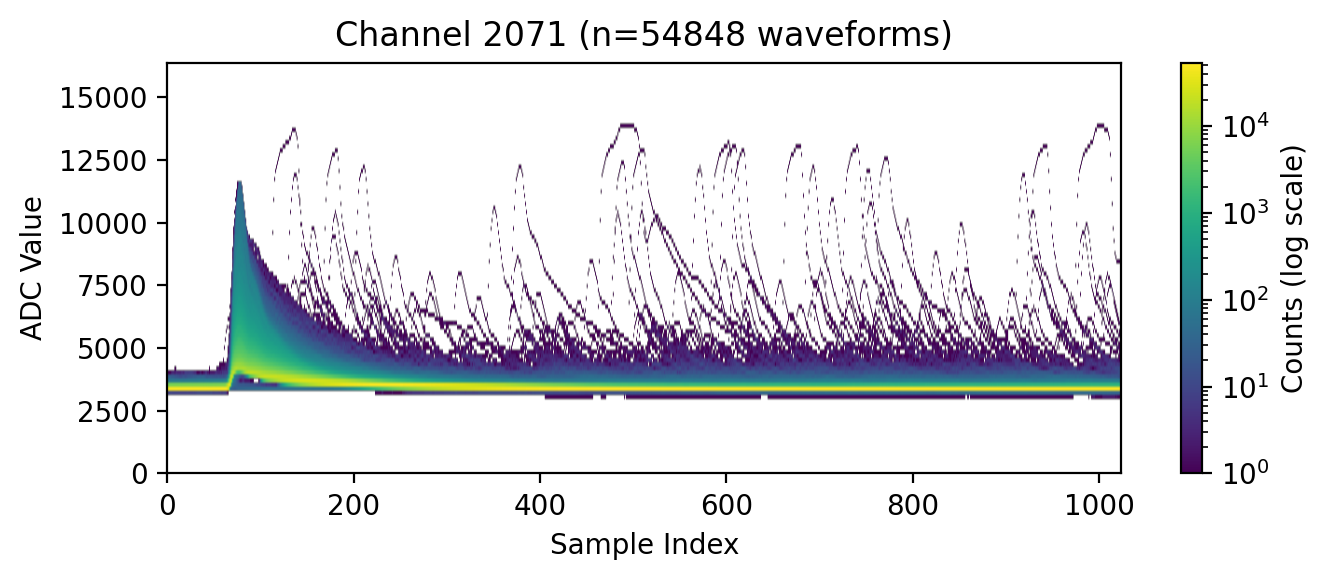

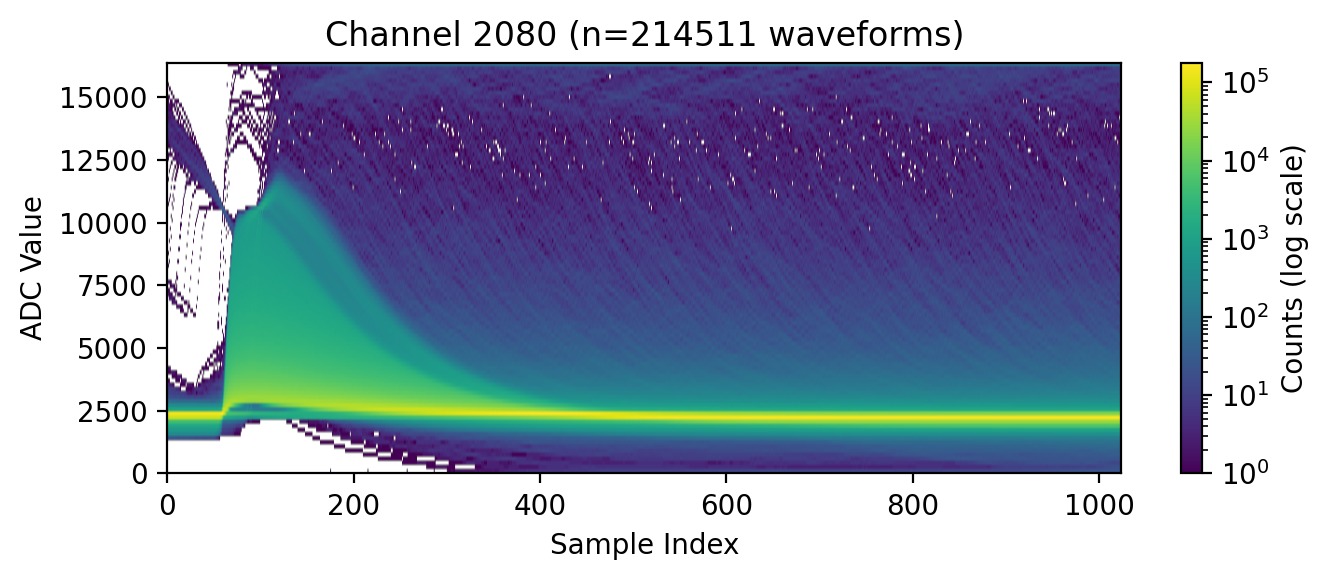

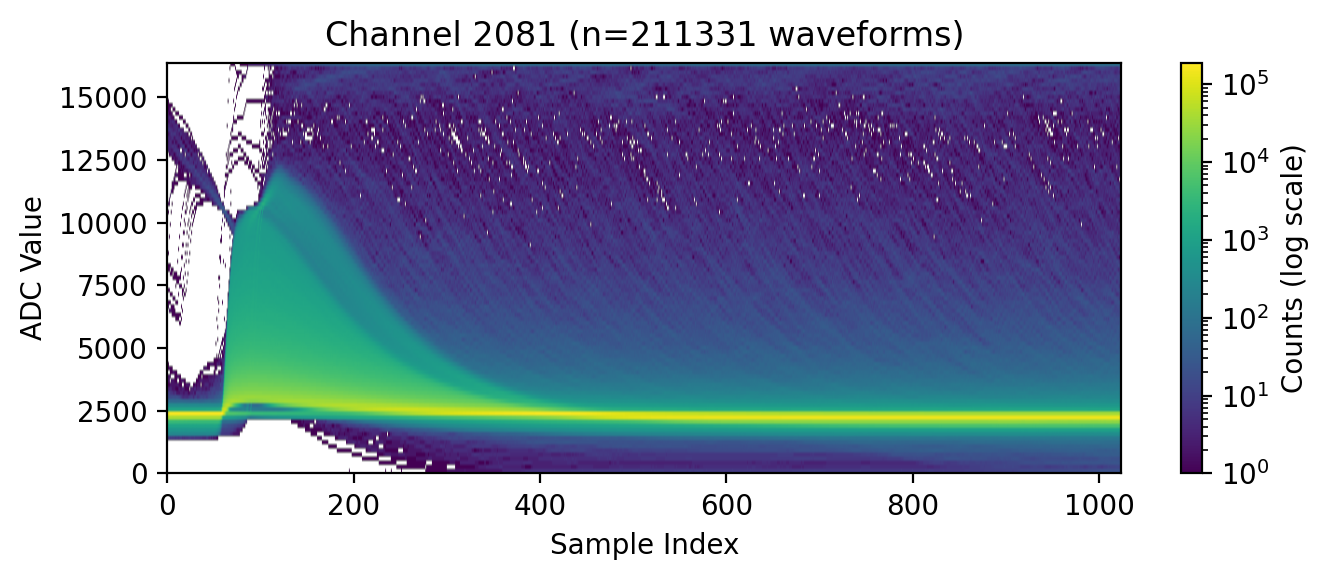

In [23]:
for ch in valid_channels:
    plt.figure(dpi=200,figsize=(7,3))
    h = hist_by_channel[ch]

    if counts_by_channel[ch] == 0:
        continue

    im = plt.imshow(
        h.T,
        origin="lower",
        aspect="auto",
        extent=[0, n_samples, adc_min, adc_max],
        cmap="viridis",
        norm=LogNorm(vmin=1),
    )

    plt.xlabel("Sample Index")
    plt.ylabel("ADC Value")
    plt.title(f"Channel {ch} (n={counts_by_channel[ch]} waveforms)")
    plt.colorbar(im, label="Counts (log scale)")

    plt.tight_layout()
    plt.savefig(f"allwaveforms_channel_{ch}.pdf", bbox_inches="tight", transparent=True)
    plt.savefig(f"allwaveforms_channel_{ch}.png", bbox_inches="tight", transparent=True)